In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
from data_io import load_from_sqlite

DB_PATH = '../data/processed/wec_bop.db'

event_model = load_from_sqlite("SELECT * FROM event_model_features", DB_PATH)
stint_features = load_from_sqlite("SELECT * FROM stint_features", DB_PATH)

print(f"event_model: {len(event_model):,} rows")
print(f"stint_features: {len(stint_features):,} rows")

event_model: 305 rows
stint_features: 2,570 rows


In [3]:
plt.rcParams.update({
    'figure.facecolor': '#f7f6f2',
    'axes.facecolor':   '#f7f6f2',
    'axes.grid':        True,
    'grid.color':       '#dcd9d5',
    'grid.linewidth':   0.6,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

COLORS = {
    'LMH':  '#01696f',
    'LMDh': '#da7101',
    'GT3':  '#006494',
    'neutral': '#7a7974',
    'positive': '#a12c7b',
    'negative': '#437a22',
}

print("Style configured")

Style configured


In [4]:
summary = (
    event_model
    .groupby(['class_normalized', 'homologation_group', 'car_model_key', 'manufacturer'])
    .agg(
        events            = ('event', 'nunique'),
        years             = ('year', 'nunique'),
        avg_delta         = ('baseline_delta', 'mean'),
        median_delta      = ('baseline_delta', 'median'),
        avg_consistency   = ('consistency_score', 'mean'),
        avg_long_run      = ('long_run_score', 'median'),
        avg_track_balance = ('track_balance_score', 'mean'),
    )
    .round(3)
    .reset_index()
    .sort_values('avg_delta')
)

print(summary[['class_normalized', 'homologation_group',
               'car_model_key', 'events', 'avg_delta']].to_string(index=False))

class_normalized homologation_group        car_model_key  events  avg_delta
        HYPERCAR                LMH           Toyota_LMH      13     -0.500
        HYPERCAR                LMH          Ferrari_LMH      10     -0.449
             GT3                GT3      Lamborghini_GT3       6     -0.312
             GT3                GT3     Aston Martin_GT3       8     -0.178
             GT3                GT3          Ferrari_GT3       8     -0.174
             GT3                GT3          Porsche_GT3       8     -0.165
        HYPERCAR               LMDh        Cadillac_LMDh      10     -0.079
        HYPERCAR               LMDh         Porsche_LMDh      10     -0.007
             GT3                GT3            Lexus_GT3       8      0.048
             GT3                GT3        Chevrolet_GT3       8      0.090
             GT3                GT3          McLaren_GT3       8      0.134
        HYPERCAR               LMDh             BMW_LMDh       8      0.144
            

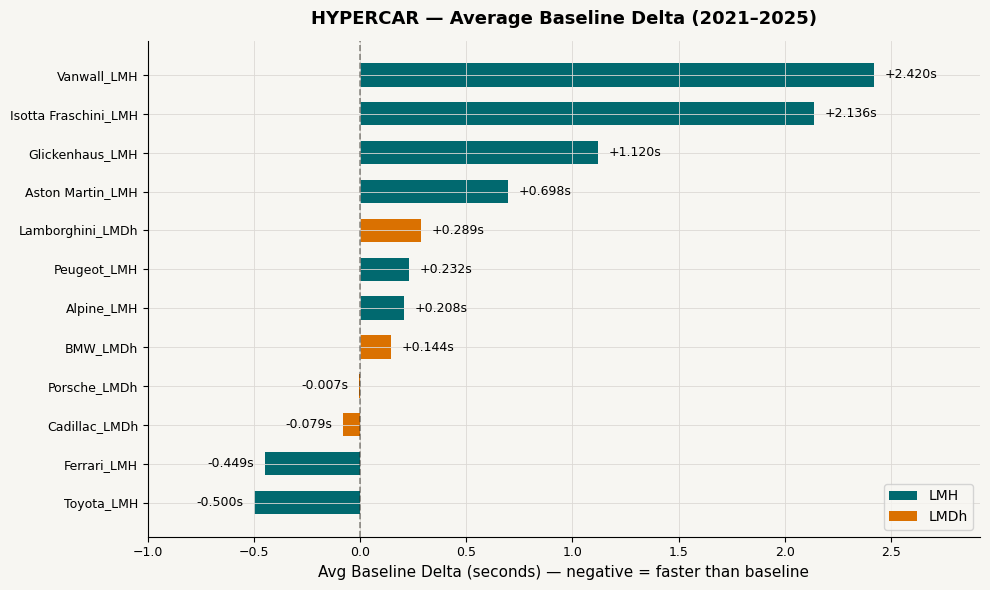

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

hc = summary[summary['class_normalized'] == 'HYPERCAR'].sort_values('avg_delta')

colors = [COLORS[h] for h in hc['homologation_group']]
bars = ax.barh(hc['car_model_key'], hc['avg_delta'], color=colors, height=0.6)

ax.axvline(0, color='#28251d', linewidth=1.2, linestyle='--', alpha=0.5)

# Подписи значений
for bar, val in zip(bars, hc['avg_delta']):
    offset = 0.05 if val >= 0 else -0.05
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}s', va='center', ha=ha, fontsize=9)

# Легенда для групп
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['LMH'],  label='LMH'),
    Patch(facecolor=COLORS['LMDh'], label='LMDh'),
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.8)

ax.set_xlabel('Avg Baseline Delta (seconds) — negative = faster than baseline')
ax.set_title('HYPERCAR — Average Baseline Delta (2021–2025)', fontweight='bold', pad=12)
ax.set_xlim(hc['avg_delta'].min() - 0.5, hc['avg_delta'].max() + 0.5)

plt.tight_layout()
plt.savefig('../reports/hypercar_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

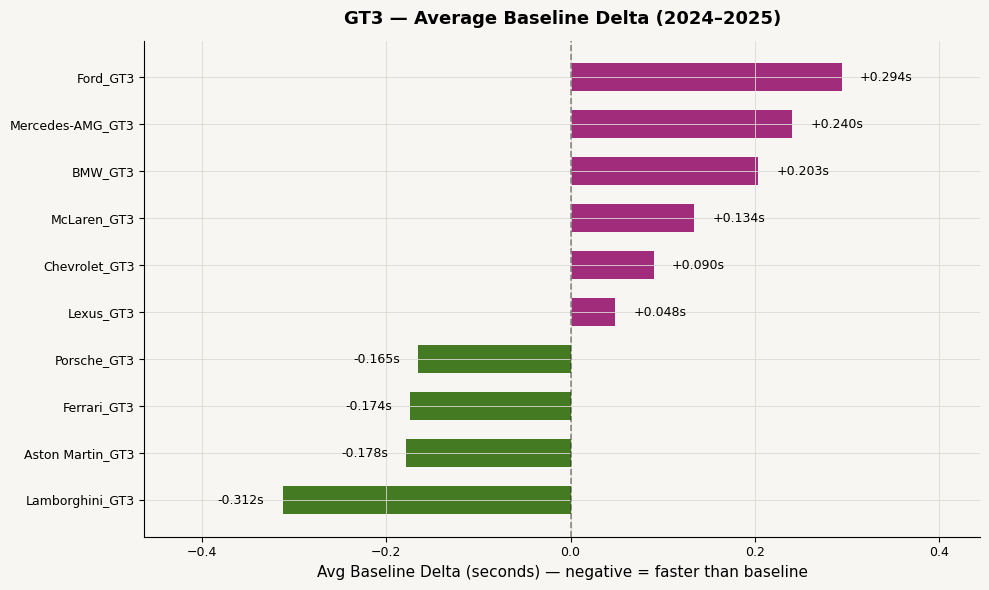

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

gt3 = summary[summary['class_normalized'] == 'GT3'].sort_values('avg_delta')

bar_colors = [COLORS['negative'] if v < 0 else COLORS['positive']
              for v in gt3['avg_delta']]
bars = ax.barh(gt3['car_model_key'], gt3['avg_delta'], color=bar_colors, height=0.6)

ax.axvline(0, color='#28251d', linewidth=1.2, linestyle='--', alpha=0.5)

for bar, val in zip(bars, gt3['avg_delta']):
    offset = 0.02 if val >= 0 else -0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}s', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Avg Baseline Delta (seconds) — negative = faster than baseline')
ax.set_title('GT3 — Average Baseline Delta (2024–2025)', fontweight='bold', pad=12)
ax.set_xlim(gt3['avg_delta'].min() - 0.15, gt3['avg_delta'].max() + 0.15)

plt.tight_layout()
plt.savefig('../reports/gt3_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

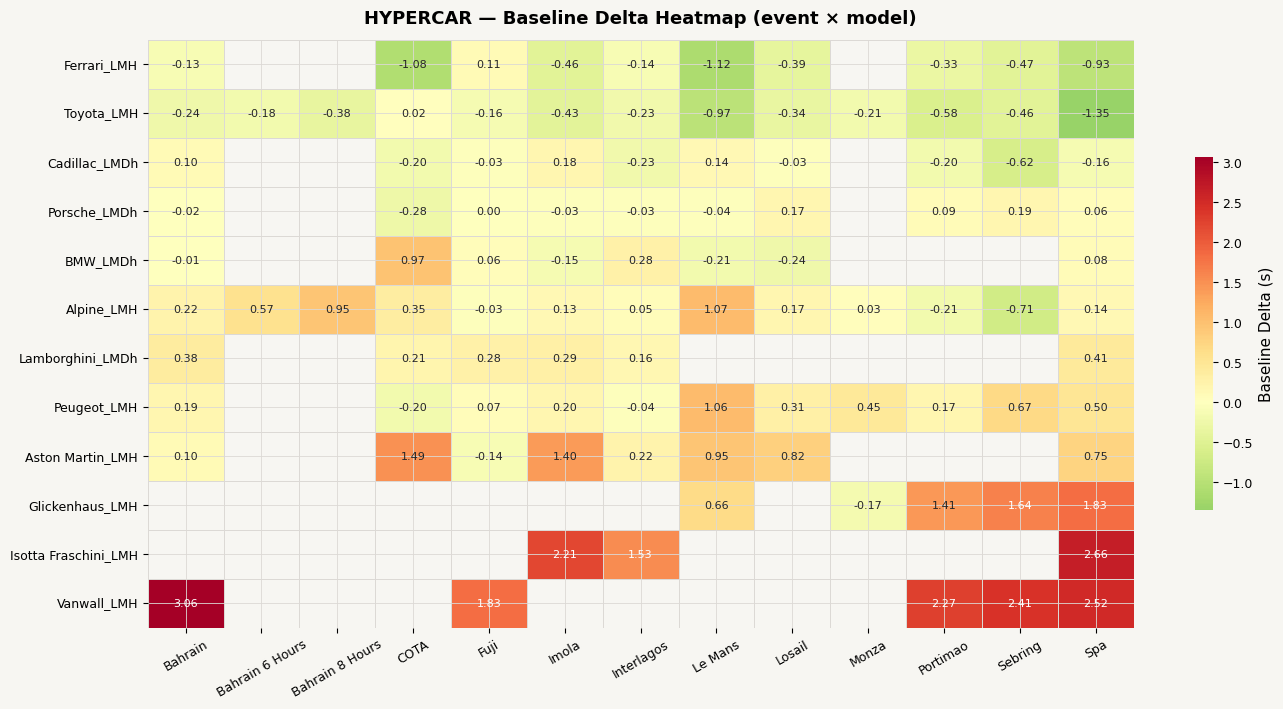

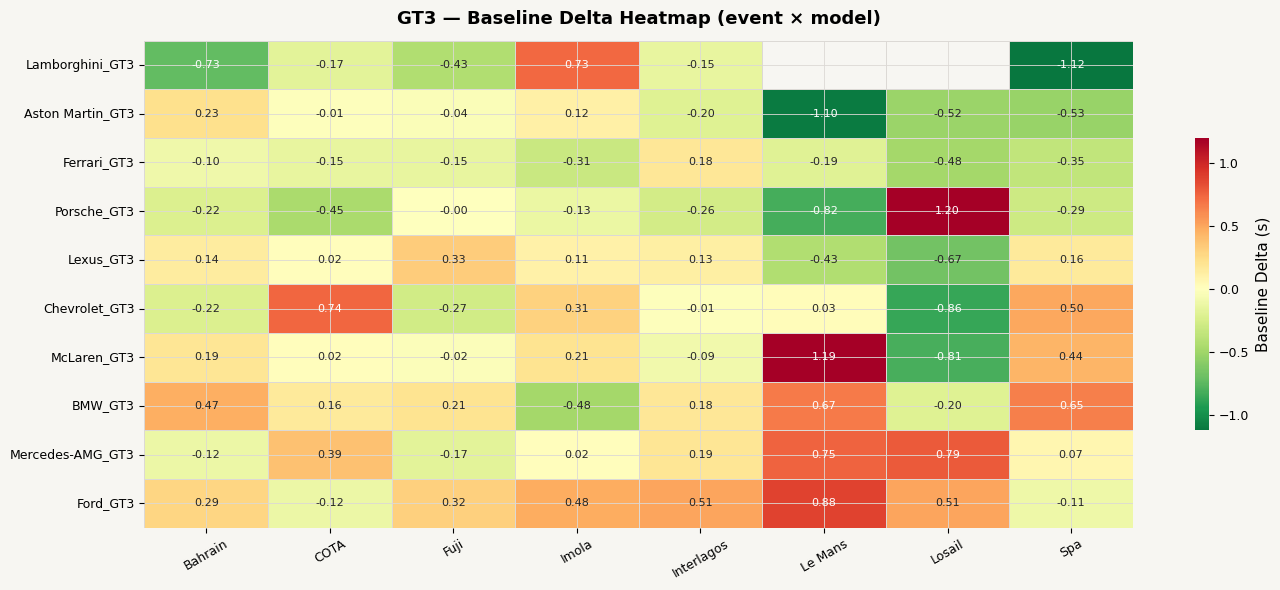

In [7]:
for cls, grp_col in [('HYPERCAR', 'homologation_group'), ('GT3', None)]:
    subset = event_model[event_model['class_normalized'] == cls]

    pivot = subset.pivot_table(
        index='car_model_key',
        columns='event',
        values='baseline_delta',
        aggfunc='mean'
    ).round(2)

    # Сортируем по среднему delta
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

    fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.6)))

    sns.heatmap(
        pivot,
        ax=ax,
        cmap='RdYlGn_r',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.4,
        linecolor='#dcd9d5',
        cbar_kws={'label': 'Baseline Delta (s)', 'shrink': 0.6},
        annot_kws={'size': 8}
    )

    ax.set_title(f'{cls} — Baseline Delta Heatmap (event × model)',
                 fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(f'../reports/{cls.lower()}_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

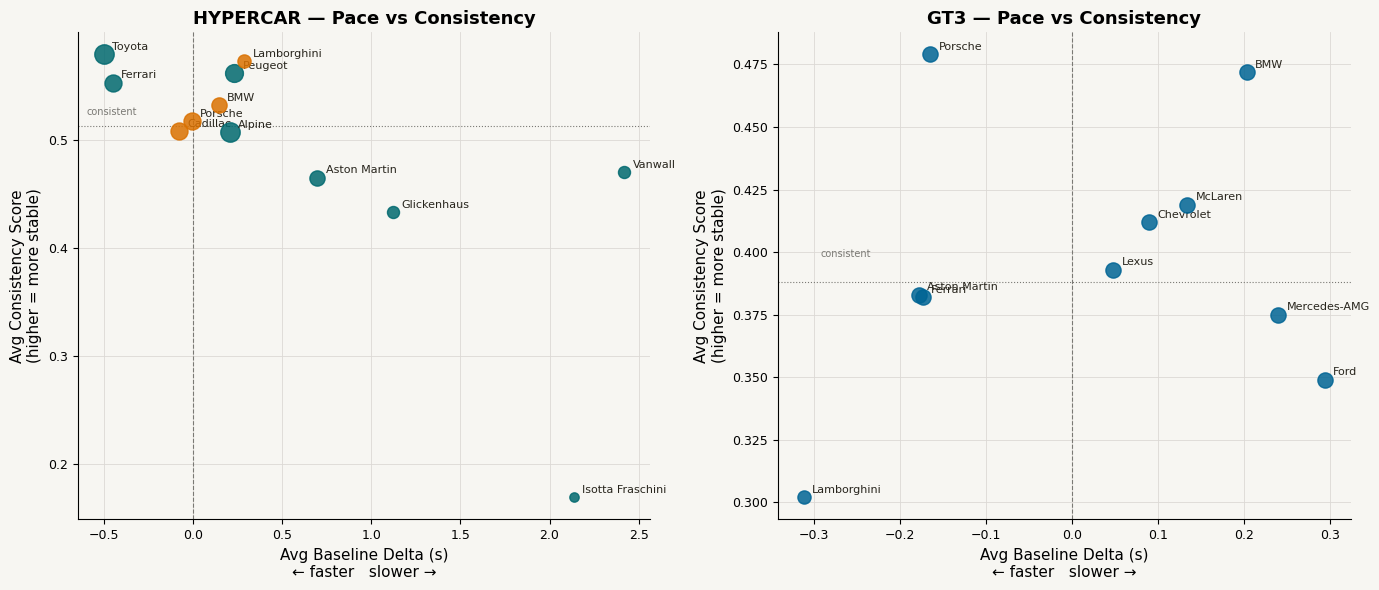

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cls in zip(axes, ['HYPERCAR', 'GT3']):
    subset = summary[summary['class_normalized'] == cls]

    for _, row in subset.iterrows():
        color = COLORS.get(row['homologation_group'], COLORS['neutral'])
        ax.scatter(row['avg_delta'], row['avg_consistency'],
                   s=row['events'] * 15,
                   color=color, alpha=0.85, zorder=3)
        ax.annotate(
            row['manufacturer'],
            xy=(row['avg_delta'], row['avg_consistency']),
            xytext=(6, 3), textcoords='offset points',
            fontsize=8, color='#28251d'
        )

    ax.axvline(0, color='#7a7974', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Avg Baseline Delta (s)\n← faster   slower →')
    ax.set_ylabel('Avg Consistency Score\n(higher = more stable)')
    ax.set_title(f'{cls} — Pace vs Consistency', fontweight='bold')

    # Квадранты
    ymed = subset['avg_consistency'].median()
    ax.axhline(ymed, color='#7a7974', linewidth=0.8, linestyle=':')
    ax.text(ax.get_xlim()[0] + 0.05, ymed + 0.01,
            'consistent', fontsize=7, color='#7a7974')

plt.tight_layout()
plt.savefig('../reports/pace_vs_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

> **TODO (v2):** Нормализовать названия трасс — `Bahrain 6 Hours` и `Bahrain 8 Hours`
> объединить в `Bahrain` через `EVENT_NORMALIZATION` в `config.py`.

C:\Users\Matvey\AppData\Local\Temp\ipykernel_40132\3242990359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Matvey\AppData\Local\Temp\ipykernel_40132\3242990359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


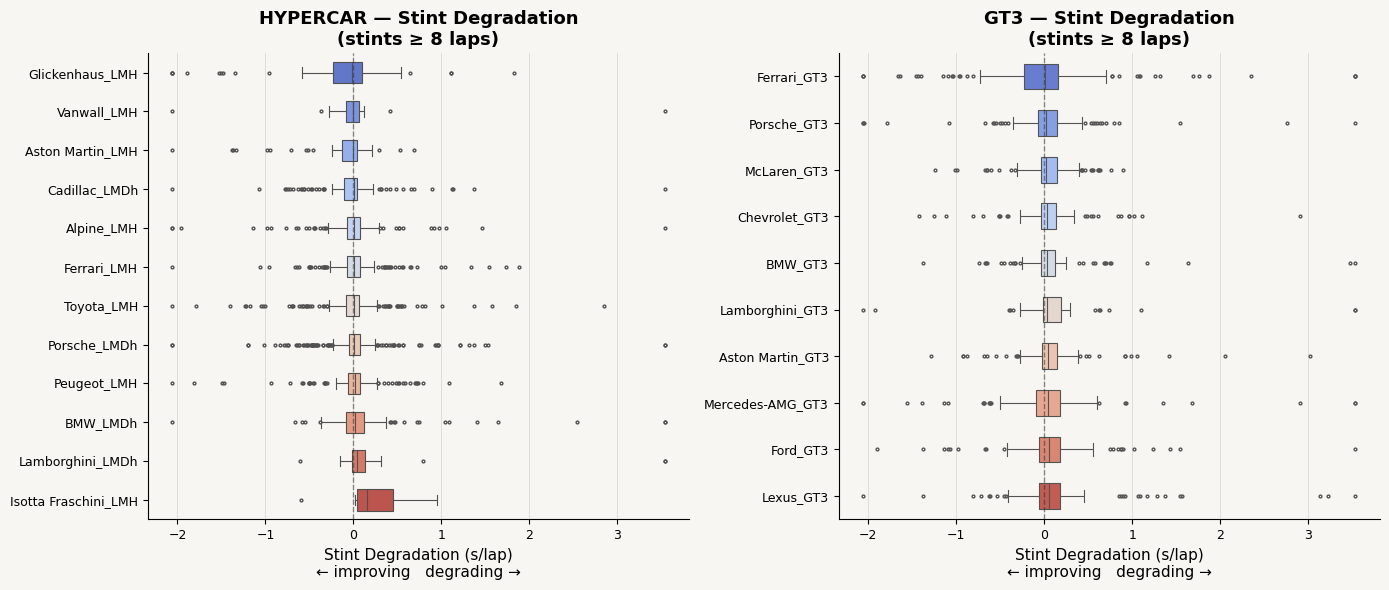

In [9]:
# More than 8 laps
long_stints = stint_features[stint_features['valid_laps_count'] >= 8].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cls in zip(axes, ['HYPERCAR', 'GT3']):
    subset = long_stints[long_stints['class_normalized'] == cls]

    order = (subset.groupby('car_model_key')['stint_degradation']
             .median().sort_values().index)

    sns.boxplot(
        data=subset,
        x='stint_degradation',
        y='car_model_key',
        order=order,
        ax=ax,
        palette='coolwarm',
        width=0.55,
        linewidth=0.8,
        fliersize=2,
    )

    ax.axvline(0, color='#28251d', linewidth=1.0, linestyle='--', alpha=0.5)
    ax.set_xlabel('Stint Degradation (s/lap)\n← improving   degrading →')
    ax.set_ylabel('')
    ax.set_title(f'{cls} — Stint Degradation\n(stints ≥ 8 laps)', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/stint_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Выводы по Balance Analyzer

### HYPERCAR

**Доминирование Toyota и Ferrari LMH** подтверждается на всех уровнях анализа:
быстрее baseline на -0.50 и -0.45 сек, стабильны по трассам, управляемая деградация.
Это системное преимущество, а не результат отдельных событий.

**LMDh группа сбалансирована:** Porsche (-0.007) и Cadillac (-0.079) держатся
у baseline. BMW пока отстаёт (+0.144) — класс дебютировал в 2024 и прогрессирует.

**Аутсайдеры с низким confidence:** Vanwall (+2.42) и Isotta Fraschini (+2.14)
имеют слишком мало событий (3–5) для надёжной рекомендации.

**Трассовая нестабильность Alpine:** на Bahrain 8 Hours +0.95, на Le Mans +1.07,
но на Spa -0.71 — высокий `track_balance_score` снизит их confidence в Recommender.

### GT3

**Поле в пределах 0.6 секунды** — BoP в LMGT3 работает. Тем не менее
Lamborghini (-0.31) и Aston Martin (-0.18) системно быстрее, Ford (+0.29)
и Mercedes-AMG (+0.24) системно медленнее.


**Lexus** — самая нестабильная деградация в классе, широкий разброс стинтов.
**Ferrari GT3** — наиболее предсказуемая деградация, узкий boxplot.

### Ограничения

- GT3 только 2 сезона (2024–2025) — недостаточно для cross-season stability
- Bahrain представлен тремя разными форматами событий (TODO: нормализовать в v2)
- Wet-анализ ограничен малым числом дождевых гонок в датасете
